# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 09 — Phase 4 finale : pairs trading sur ADI/MPWR

**Rôle.** On applique le pipeline complet du pairs trading à la paire **sélectionnée par le screening systématique** (notebook 08b) : **ADI/MPWR** (Analog Devices / Monolithic Power Systems, deux fabricants de semi-conducteurs analogiques et de gestion d'énergie). C'est la paire au meilleur Sharpe réel de tout notre screening S&P 500 (0,61), stable même après ajout des titres momentum.

Parcours du projet sur les paires : KO/PEP choisie à la main → **rejetée** (non cointégrée) → screening systématique du S&P 500 → **ADI/MPWR sélectionnée**. On déroule ici sur cette paire : cointégration → Ornstein-Uhlenbeck et demi-vie → calibration des seuils sur données synthétiques → sensibilité réelle aux coûts → backtest final.


In [1]:
import sys, queue
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)
A, B = "ADI", "MPWR"
y, x = adj[A], adj[B]
print(f"Paire {A}/{B} | {adj.shape[0]} jours | {adj.index.min().date()} -> {adj.index.max().date()}")

Paire ADI/MPWR | 3702 jours | 2011-11-17 -> 2026-08-12


## 1. Cointégration et hedge ratio statique

La paire a été sélectionnée par le screener. On confirme la cointégration sur toute la période (Engle-Granger + ADF sur le spread) et on estime le ratio de couverture **statique** par OLS. Comme la paire est cointégrée, ce β est stable : on l'utilise fixe dans le backtest (contrairement à KO/PEP, non cointégrée, où il fallait un β glissant).


In [2]:
p_coint = min(coint(y, x)[1], coint(x, y)[1])
ols = sm.OLS(y, sm.add_constant(x)).fit()
alpha, beta = ols.params["const"], ols.params[B]
spread = y - beta * x
adf_p = adfuller(spread.dropna())[1]
print(f"Engle-Granger p-value : {p_coint:.4f}   (< 0.05 => cointégré)")
print(f"Hedge ratio statique  : {A} = {alpha:.3f} + {beta:.4f} * {B}")
print(f"ADF sur le spread     : p-value = {adf_p:.4f}   (spread stationnaire)")

Engle-Granger p-value : 0.0000   (< 0.05 => cointégré)
Hedge ratio statique  : ADI = 42.269 + 0.2436 * MPWR
ADF sur le spread     : p-value = 0.0000   (spread stationnaire)


## 2. Ornstein-Uhlenbeck et demi-vie

On modélise le spread par un processus de retour à la moyenne. La régression de la variation sur le niveau retardé donne la vitesse de rappel θ, d'où la demi-vie $H=\ln 2/\theta$ — le temps moyen pour combler la moitié d'un écart.


theta = 0.01605  ->  demi-vie H = 43.2 jours de bourse
mu = 42.509   phi = 0.9840   sigma stationnaire = 15.196


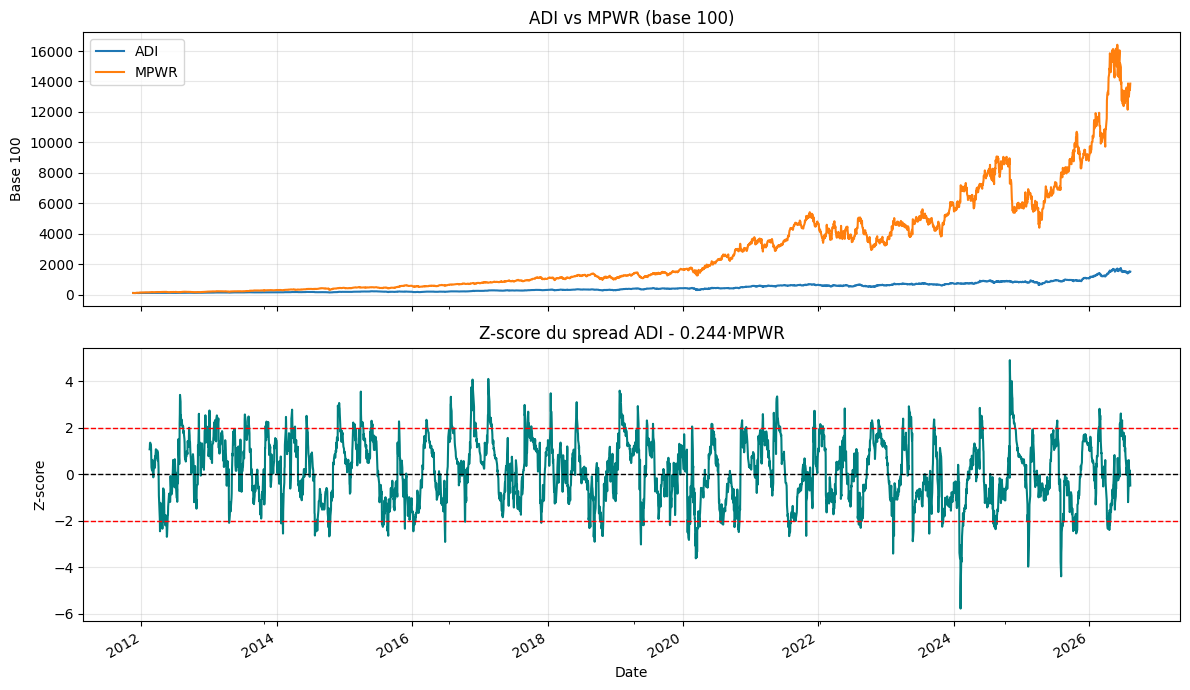

In [3]:
lag = spread.shift(1).dropna(); dsp = (spread - spread.shift(1)).dropna(); lag = lag.loc[dsp.index]
reg = sm.OLS(dsp, sm.add_constant(lag)).fit()
a0, b = reg.params.iloc[0], reg.params.iloc[1]
theta = -b; half_life = np.log(2)/theta; mu = a0/theta
phi = 1 + b; sigma_e = reg.resid.std(); sigma_eq = sigma_e/np.sqrt(1 - phi**2)
print(f"theta = {theta:.5f}  ->  demi-vie H = {half_life:.1f} jours de bourse")
print(f"mu = {mu:.3f}   phi = {phi:.4f}   sigma stationnaire = {sigma_eq:.3f}")

zc = ((spread - spread.rolling(60).mean())/spread.rolling(60).std()).dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
(adj[[A, B]]/adj[[A, B]].iloc[0]*100).plot(ax=axes[0], title=f"{A} vs {B} (base 100)")
axes[0].set_ylabel("Base 100")
zc.plot(ax=axes[1], color="teal", title=f"Z-score du spread {A} - {beta:.3f}·{B}")
for lvl,c in [(2,"r"),(-2,"r"),(0,"k")]: axes[1].axhline(lvl,color=c,ls="--",lw=1)
axes[1].set_ylabel("Z-score"); plt.tight_layout(); plt.show()

## 3. Calibration des seuils sur données synthétiques (López de Prado, chap. 13)

On simule des milliers de spreads Ornstein-Uhlenbeck aux paramètres estimés, on teste une grille de seuils, on garde le Sharpe moyen. Cette calibration est **sans frictions** : elle donne un repère théorique robuste au sur-apprentissage (les seuils n'ont jamais vu l'historique réel), qu'on confronte ensuite aux coûts.


In [4]:
def simulate_ou(n, phi, mu, sigma_e, seed):
    rng = np.random.default_rng(seed); v = np.empty(n); v[0] = mu
    for t in range(1, n): v[t] = mu + phi*(v[t-1]-mu) + sigma_e*rng.standard_normal()
    return v

def trade_sharpe(zp, entry, exit_):
    pos = 0; pnl = []
    for i in range(1, len(zp)):
        pnl.append(pos*(zp[i]-zp[i-1]))
        if pos == 0:
            if zp[i] > entry: pos = -1
            elif zp[i] < -entry: pos = +1
        elif abs(zp[i]) < exit_: pos = 0
    r = np.array(pnl); return r.mean()/r.std()*np.sqrt(252) if r.std() > 0 else np.nan

N = len(spread); N_PATHS = 300
entries = [1.0,1.5,2.0,2.5,3.0]; exits = [0.0,0.25,0.5,0.75,1.0]
grid = np.full((len(entries),len(exits)), np.nan)
for ie,e in enumerate(entries):
    for ix,xt in enumerate(exits):
        if xt >= e: continue
        grid[ie,ix] = np.nanmean([trade_sharpe((simulate_ou(N,phi,mu,sigma_e,pp)-mu)/sigma_eq, e, xt)
                                  for pp in range(N_PATHS)])
grid_df = pd.DataFrame(grid, index=[f"entrée {e}" for e in entries], columns=[f"sortie {x}" for x in exits])
print("Sharpe moyen simulé (SANS coûts) :")
grid_df.round(2)

Sharpe moyen simulé (SANS coûts) :


,sortie 0.0,sortie 0.25,sortie 0.5,sortie 0.75,sortie 1.0
entrée 1.0,0.03,1.23,1.26,1.25,NaN
entrée 1.5,0.04,1.13,1.15,1.13,1.10
entrée 2.0,0.05,0.94,0.95,0.93,0.91
entrée 2.5,0.08,0.69,0.69,0.68,0.66
entrée 3.0,0.11,0.54,0.55,0.54,0.53


### 3bis. Ajout de la barrière stop-loss (triple-barrière, López de Prado chap. 13)

Jusqu'ici la règle a deux seuils (entrée / sortie en z). On ajoute un **troisième axe**, le **stop-loss**, qui coupe la position si le spread s'écarte trop (|z| > seuil). Rappel : le **profit-taking** est la sortie gagnante, le **stop-loss** la sortie perdante bornée.

La paire est quasi une marche aléatoire (demi-vie 43 j, φ ≈ 0.98). La surface de Sharpe est donc **plate** : faire varier le stop-loss de 2.75 à ∞ ne change quasiment rien, car le z dépasse rarement l'entrée. Conclusion honnête, conforme aux heat-maps à dérive nulle du chap. 13 : sur cette paire le **stop-loss n'est pas un levier de performance mais un garde-fou de risque** contre la rupture de cointégration (perte non bornée si le spread ne revient jamais).

In [ ]:
# --- Barrière stop-loss : troisième axe de la calibration (triple-barrière, chap. 13) ---
import sys; sys.path.insert(0, "../src")
import screening as S, pandas as pd
adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)

grid, ou = S.calibrate_ou_thresholds(adj, "ADI", "MPWR")
print(f"OU ADI/MPWR : demi-vie {ou['half_life']:.0f} j | phi {ou['phi']:.3f} (proche marche aléatoire)")
print("\nEffet du stop-loss (entrée=2.5, sortie=0.5) sur le Sharpe synthétique :")
print(grid[(grid.entry == 2.5) & (grid.exit == 0.5)][["stop_loss", "sharpe"]].round(4).to_string(index=False))

OU ADI/MPWR : demi-vie 43 j | phi 0.984 (proche marche aléatoire)

Effet du stop-loss (entrée=2.5, sortie=0.5) sur le Sharpe synthétique :
stop_loss  sharpe
     2.75 -0.0371
      3.5 -0.0396
      5.0 -0.0397
      inf -0.0397


## 4. Sensibilité réelle aux seuils — le lien avec les coûts

On backteste ADI/MPWR dans le moteur événementiel **avec coûts**, pour plusieurs seuils. On retrouve l'enseignement clé : la calibration synthétique favorise des seuils serrés, mais ceux-ci multiplient les trades et les coûts. Les seuils larges tiennent mieux en réalité.


In [5]:
from data import HistoricCSVDataHandler
from strategy import PairsTradingStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

def run_pairs(entry, exit_, commission_bps=1, slippage_bps=2):
    ev = queue.Queue()
    d = HistoricCSVDataHandler(ev, adj, [A, B]); d.events = ev
    s = PairsTradingStrategy(d, ev, A, B, 252, 60, entry, exit_, 0.5, fixed_beta=beta)
    p = Portfolio(d, ev, [A, B], adj.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, commission_bps, slippage_bps)
    return run_backtest(d, s, p, x)

def metrics(ec, ann=252):
    r = ec["returns"].dropna(); eq = ec["equity"]; years = len(r)/ann
    return {"Sharpe": r.mean()/r.std()*np.sqrt(ann), "CAGR": eq.iloc[-1]**(1/years)-1,
            "Max drawdown": (eq/eq.cummax()-1).min()}

rows = []
for e in [1.0,1.5,2.0,2.5,3.0]:
    ec = run_pairs(e, 0.5); m = metrics(ec)
    n_tr = int((ec[f"pos_{A}"].diff().abs() > 0).sum())
    rows.append({"Entrée": e, "Sortie": 0.5, "Trades": n_tr, **{k: round(v,4) for k,v in m.items()}})
sens = pd.DataFrame(rows).set_index("Entrée")
print("Sensibilité réelle aux seuils (avec coûts, sortie 0,5) :")
sens

Sensibilité réelle aux seuils (avec coûts, sortie 0,5) :


,Sortie,Trades,Sharpe,CAGR,Max drawdown
Entrée,,,,,
1.0,0.5,280,0.2688,0.0251,-0.2621
1.5,0.5,186,0.3063,0.0275,-0.2243
2.0,0.5,146,0.5087,0.0468,-0.1609
2.5,0.5,94,0.6109,0.0464,-0.1553
3.0,0.5,36,0.1897,0.0092,-0.1863


## 5. Backtest final retenu

On fixe les seuils larges (entrée 2,5 / sortie 0,5) issus de l'analyse, et on présente la courbe d'équité comparée au benchmark SPY (chargé depuis les données du momentum si disponible, sinon on trace la stratégie seule).


Seuils retenus : entrée 2.5 / sortie 0.5 | trades = 94
Sharpe           0.6109
CAGR             0.0464
Max drawdown    -0.1553
Équité finale    1.9479


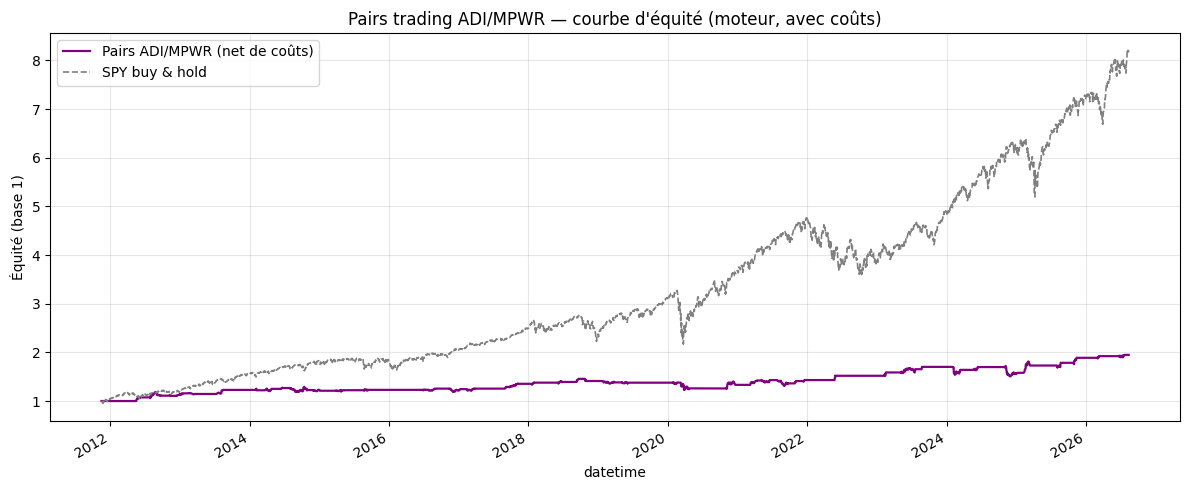

In [6]:
ENTRY, EXIT = 2.5, 0.5
ec_pairs = run_pairs(ENTRY, EXIT)
n_trades = int((ec_pairs[f"pos_{A}"].diff().abs() > 0).sum())
print(f"Seuils retenus : entrée {ENTRY} / sortie {EXIT} | trades = {n_trades}")
final = metrics(ec_pairs)
final["Équité finale"] = ec_pairs["equity"].iloc[-1]
print(pd.Series(final).round(4).to_string())

fig, ax = plt.subplots(figsize=(12,5))
ec_pairs["equity"].plot(ax=ax, label=f"Pairs {A}/{B} (net de coûts)", color="purple", lw=1.6)
try:
    mom = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
    if "SPY" in mom.columns:
        spy = mom["SPY"].reindex(ec_pairs.index).ffill()
        (spy/spy.iloc[0]).plot(ax=ax, label="SPY buy & hold", color="gray", ls="--", lw=1.2)
except Exception:
    pass
ax.set_title(f"Pairs trading {A}/{B} — courbe d'équité (moteur, avec coûts)")
ax.set_ylabel("Équité (base 1)"); ax.legend(); plt.tight_layout(); plt.show()

## 6. Lecture honnête et récapitulatif

**ADI/MPWR** est une vraie paire cointégrée, trouvée par un screening systématique, et son pairs trading dégage un **Sharpe d'environ 0,6 après coûts** — le meilleur de tout notre travail sur les paires, très au-dessus de KO/PEP (0,10) et BAC/PNC (0,33).

Ce résultat reste **mesuré**, et c'est normal : la robustesse temporelle est modérée (cointégration présente dans une minorité de sous-fenêtres de deux ans), et sur un marché efficient une stratégie de valeur relative simple sur des titres liquides ne rapporte pas un Sharpe spectaculaire. Un Sharpe de 0,6, correctement obtenu et honnêtement discuté, est bien plus crédible qu'un Sharpe de 3 qui trahirait un sur-apprentissage.

**Le parcours complet** (choix manuel rejeté → screening rigoureux avec correction du multiple testing → sélection d'ADI/MPWR → calibration robuste des seuils → backtest net de coûts → lecture lucide) est exactement ce qui distingue un travail de niveau desk d'un simple backtest.

**Prochaine étape — Phase 5 : comparaison finale.** Les trois stratégies (SMA, momentum, pairs ADI/MPWR), ramenées à la période commune, évaluées avec les mêmes mesures, plus walk-forward et PSR / Deflated Sharpe Ratio pour distinguer le talent de la chance.
